In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
from statsmodels.stats.weightstats import DescrStatsW

plt.style.use('seaborn-v0_8')

In [2]:
data = pd.read_csv('smaller.csv', dtype={'SOCP': str})
data['inc2024'] = data.PINCP * data.ADJINC / 1_000_000
print(data.shape, data.PWGTP.sum())

data = data.dropna(subset=['PWGTP', 'ADJINC', 'PINCP'])
print(data.shape, data.PWGTP.sum())

data = data[data.inc2024 > 0]
print(data.shape, data.PWGTP.sum())

(3422888, 7) 340110990
(2912790, 7) 280613270
(2556439, 7) 245168158


In [3]:
data.sort_values('inc2024', inplace=True)

In [4]:
data['cum_people'] = data.PWGTP.cumsum()
data['cum_income'] = (data.PWGTP * data.inc2024).cumsum()

In [ ]:
np.trapezoid(

In [16]:
g = (0.5 - np.trapezoid(data.cum_income / (data.PWGTP * data.inc2024).sum(),
                        data.cum_people / data.PWGTP.sum())) / 0.5
g

np.float64(0.5212688116301785)

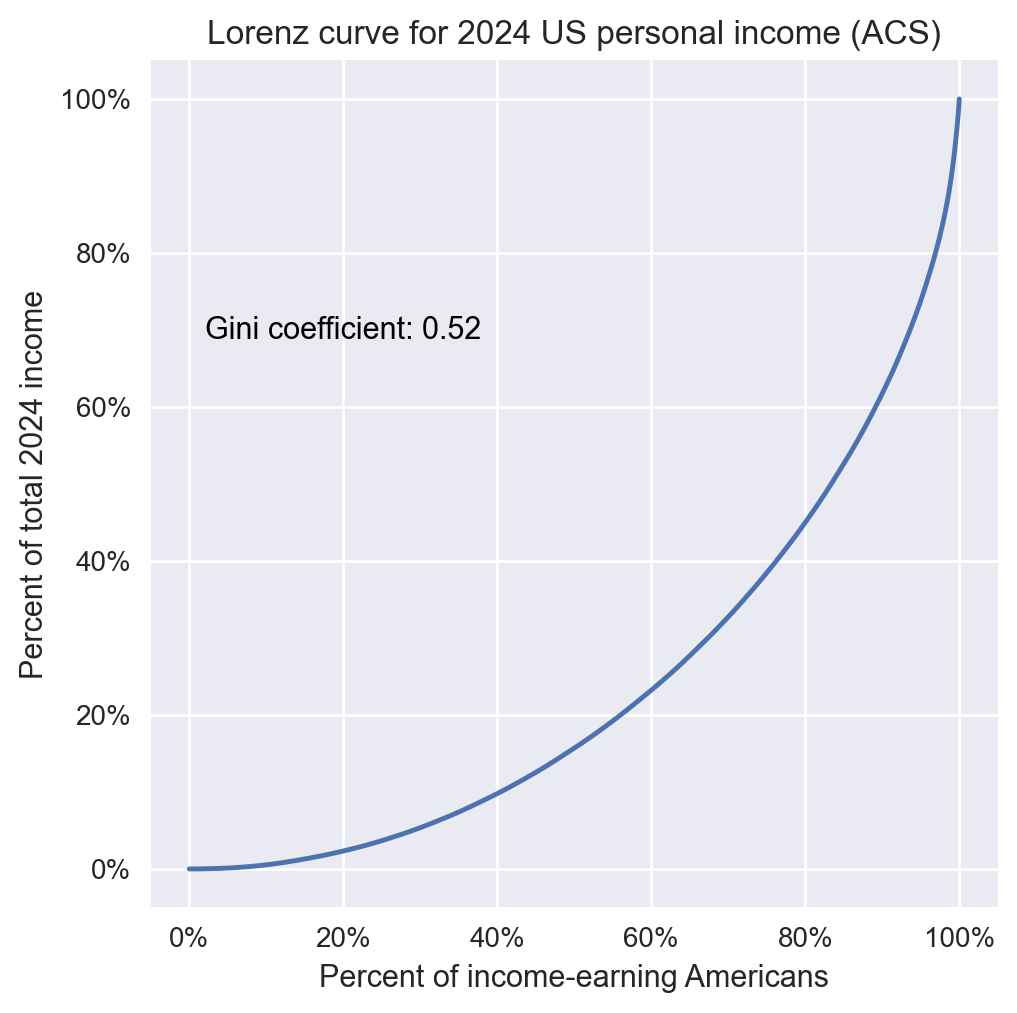

In [24]:
plt.plot(data.cum_people / data.PWGTP.sum(), data.cum_income / (data.PWGTP * data.inc2024).sum())
plt.gca().set_box_aspect(1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.xlabel('Percent of income-earning Americans')
plt.ylabel('Percent of total 2024 income')
plt.title('Lorenz curve for 2024 US personal income (ACS)')

plt.text(
            x=0.02,
            y=0.7,
            s=f'Gini coefficient: {g:.2}',
            ha='left', va='center',
            color='black', fontsize=11#, fontweight='bold'
)

plt.show()